In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [20]:
data_path = "Loan_status_2007-2020Q3.gzip"
df = pd.read_csv(data_path, low_memory=False)
print("Shape:", df.shape)

Shape: (2925493, 142)


In [5]:
df.head()

,Unnamed: 0,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,debt_settlement_flag
0,0,1077501,5000.0,5000.0,4975.0,36 months,10.65%,162.87,B,B2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
1,1,1077430,2500.0,2500.0,2500.0,60 months,15.27%,59.83,C,C4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
2,2,1077175,2400.0,2400.0,2400.0,36 months,15.96%,84.33,C,C5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
3,3,1076863,10000.0,10000.0,10000.0,36 months,13.49%,339.31,C,C1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
4,4,1075358,3000.0,3000.0,3000.0,60 months,12.69%,67.79,B,B5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N


In [6]:
df1 = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
df1['target'] = df1['loan_status'].apply(lambda x: 1 if x == 'Charged Off' else 0)
df1

,Unnamed: 0,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,debt_settlement_flag,target
0,0,1077501,5000.0,5000.0,4975.0,36 months,10.65%,162.87,B,B2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,0
1,1,1077430,2500.0,2500.0,2500.0,60 months,15.27%,59.83,C,C4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,1
2,2,1077175,2400.0,2400.0,2400.0,36 months,15.96%,84.33,C,C5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,0
3,3,1076863,10000.0,10000.0,10000.0,36 months,13.49%,339.31,C,C1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,0
4,4,1075358,3000.0,3000.0,3000.0,60 months,12.69%,67.79,B,B5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925488,105446,102556443,24000.0,24000.0,24000.0,60 months,23.99%,690.30,E,E2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,1
2925489,105447,102653304,10000.0,10000.0,10000.0,36 months,7.99%,313.32,A,A5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,0
2925490,105448,102628603,10050.0,10050.0,10050.0,36 months,16.99%,358.26,D,D1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,1
2925491,105449,102196576,6000.0,6000.0,6000.0,36 months,11.44%,197.69,B,B4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,0


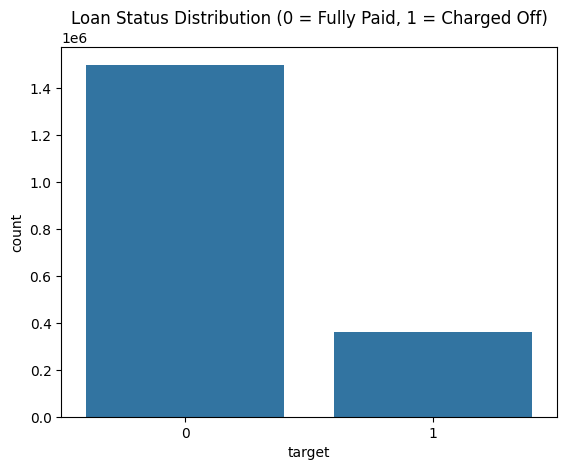

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='target', data=df1)
plt.title('Loan Status Distribution (0 = Fully Paid, 1 = Charged Off)')
plt.show()


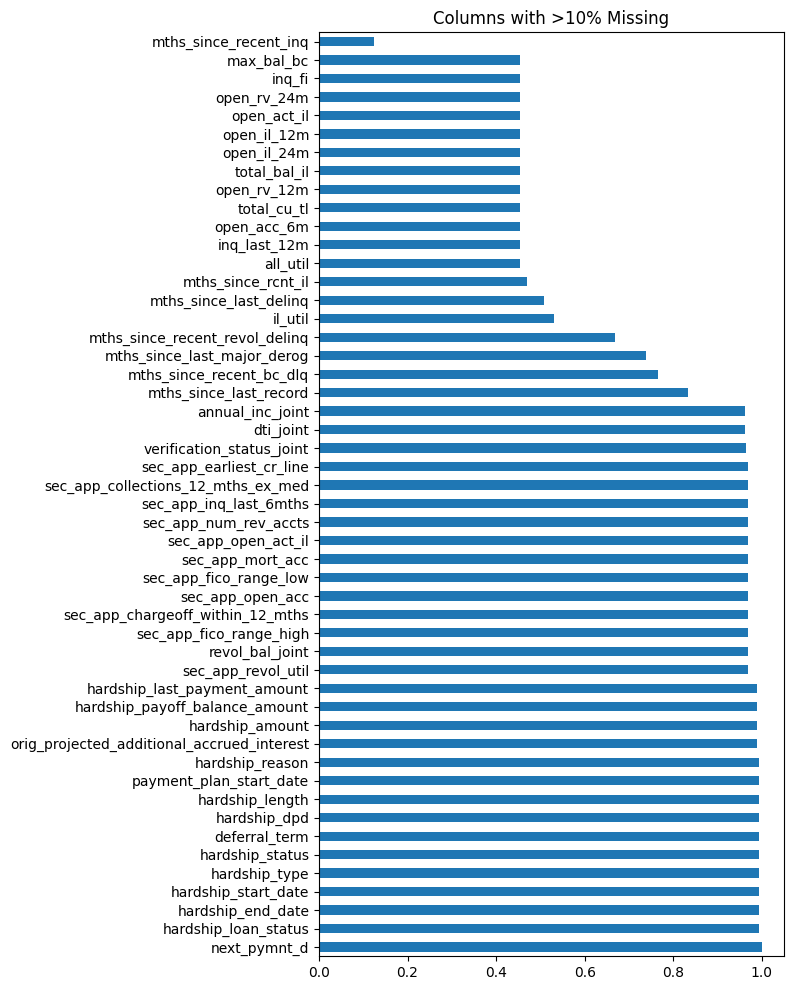

In [13]:
missing = df1.isnull().mean().sort_values(ascending=False)
missing[missing > 0.1].plot(kind='barh', figsize=(6, 12))
plt.title("Columns with >10% Missing")
plt.show()


In [14]:
threshold = 0.7
missing = df1.isnull().mean()
cols_to_drop = missing[missing > threshold].index.tolist()
df1.drop(columns=cols_to_drop, inplace=True)

print(f"Dropped {len(cols_to_drop)} columns with >70% missing values.")


Dropped 33 columns with >70% missing values.


In [15]:
drop_cols = ['id', 'member_id', 'url', 'desc', 'title', 'emp_title', 'zip_code']
df1.drop(columns=[col for col in drop_cols if col in df.columns], inplace=True)
df1

,Unnamed: 0,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,...,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,debt_settlement_flag,target
0,0,5000.0,5000.0,4975.0,36 months,10.65%,162.87,B,B2,10+ years,...,NaN,0.0,0.0,NaN,NaN,NaN,NaN,N,N,0
1,1,2500.0,2500.0,2500.0,60 months,15.27%,59.83,C,C4,< 1 year,...,NaN,0.0,0.0,NaN,NaN,NaN,NaN,N,N,1
2,2,2400.0,2400.0,2400.0,36 months,15.96%,84.33,C,C5,10+ years,...,NaN,0.0,0.0,NaN,NaN,NaN,NaN,N,N,0
3,3,10000.0,10000.0,10000.0,36 months,13.49%,339.31,C,C1,10+ years,...,NaN,0.0,0.0,NaN,NaN,NaN,NaN,N,N,0
4,4,3000.0,3000.0,3000.0,60 months,12.69%,67.79,B,B5,1 year,...,NaN,0.0,0.0,NaN,NaN,NaN,NaN,N,N,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925488,105446,24000.0,24000.0,24000.0,60 months,23.99%,690.30,E,E2,< 1 year,...,0.0,1.0,1.0,103322.0,60812.0,28200.0,64422.0,N,N,1
2925489,105447,10000.0,10000.0,10000.0,36 months,7.99%,313.32,A,A5,10+ years,...,14.3,0.0,0.0,132303.0,55863.0,34800.0,70203.0,N,N,0
2925490,105448,10050.0,10050.0,10050.0,36 months,16.99%,358.26,D,D1,8 years,...,0.0,0.0,0.0,30400.0,14300.0,9000.0,0.0,N,N,1
2925491,105449,6000.0,6000.0,6000.0,36 months,11.44%,197.69,B,B4,5 years,...,0.0,0.0,0.0,47476.0,26201.0,8100.0,34076.0,N,N,0


In [18]:
missing_summary = df1.isnull().mean()
for col, pct in missing_summary.items():
    if pct > 0:
        print(f"{col:40s} --> {pct:.1%} missing")

emp_length                               --> 6.3% missing
dti                                      --> 0.1% missing
inq_last_6mths                           --> 0.0% missing
mths_since_last_delinq                   --> 50.8% missing
revol_util                               --> 0.1% missing
last_pymnt_d                             --> 0.2% missing
last_credit_pull_d                       --> 0.0% missing
collections_12_mths_ex_med               --> 0.0% missing
tot_coll_amt                             --> 3.6% missing
tot_cur_bal                              --> 3.6% missing
open_acc_6m                              --> 45.5% missing
open_act_il                              --> 45.5% missing
open_il_12m                              --> 45.5% missing
open_il_24m                              --> 45.5% missing
mths_since_rcnt_il                       --> 47.1% missing
total_bal_il                             --> 45.5% missing
il_util                                  --> 53.1% missing
open_r

In [19]:
drop_high_missing = [
    'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m',
    'mths_since_rcnt_il', 'il_util', 'inq_fi', 'all_util',
    'total_bal_il', 'total_cu_tl', 'inq_last_12m', 'mths_since_recent_revol_delinq',
    'mths_since_last_delinq', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc'
]
df1.drop(columns=[col for col in drop_high_missing if col in df.columns], inplace=True)
df1

,Unnamed: 0,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,...,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,debt_settlement_flag,target
0,0,5000.0,5000.0,4975.0,36 months,10.65%,162.87,B,B2,10+ years,...,NaN,0.0,0.0,NaN,NaN,NaN,NaN,N,N,0
1,1,2500.0,2500.0,2500.0,60 months,15.27%,59.83,C,C4,< 1 year,...,NaN,0.0,0.0,NaN,NaN,NaN,NaN,N,N,1
2,2,2400.0,2400.0,2400.0,36 months,15.96%,84.33,C,C5,10+ years,...,NaN,0.0,0.0,NaN,NaN,NaN,NaN,N,N,0
3,3,10000.0,10000.0,10000.0,36 months,13.49%,339.31,C,C1,10+ years,...,NaN,0.0,0.0,NaN,NaN,NaN,NaN,N,N,0
4,4,3000.0,3000.0,3000.0,60 months,12.69%,67.79,B,B5,1 year,...,NaN,0.0,0.0,NaN,NaN,NaN,NaN,N,N,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925488,105446,24000.0,24000.0,24000.0,60 months,23.99%,690.30,E,E2,< 1 year,...,0.0,1.0,1.0,103322.0,60812.0,28200.0,64422.0,N,N,1
2925489,105447,10000.0,10000.0,10000.0,36 months,7.99%,313.32,A,A5,10+ years,...,14.3,0.0,0.0,132303.0,55863.0,34800.0,70203.0,N,N,0
2925490,105448,10050.0,10050.0,10050.0,36 months,16.99%,358.26,D,D1,8 years,...,0.0,0.0,0.0,30400.0,14300.0,9000.0,0.0,N,N,1
2925491,105449,6000.0,6000.0,6000.0,36 months,11.44%,197.69,B,B4,5 years,...,0.0,0.0,0.0,47476.0,26201.0,8100.0,34076.0,N,N,0


In [21]:
# Columns in df but not in df1 (i.e., dropped columns)
dropped_cols = set(df.columns) - set(df1.columns)
print("🔻 Dropped columns:")
for col in sorted(dropped_cols):
    print("-", col)

# Columns in df1 but not in df (should be none)
added_cols = set(df1.columns) - set(df.columns)
if added_cols:
    print("\n🟢 Added columns:")
    for col in sorted(added_cols):
        print("-", col)
else:
    print("\n✅ No unexpected columns were added.")


🔻 Dropped columns:
- all_util
- annual_inc_joint
- deferral_term
- dti_joint
- emp_title
- hardship_amount
- hardship_dpd
- hardship_end_date
- hardship_last_payment_amount
- hardship_length
- hardship_loan_status
- hardship_payoff_balance_amount
- hardship_reason
- hardship_start_date
- hardship_status
- hardship_type
- id
- il_util
- inq_fi
- inq_last_12m
- max_bal_bc
- mths_since_last_delinq
- mths_since_last_major_derog
- mths_since_last_record
- mths_since_rcnt_il
- mths_since_recent_bc_dlq
- mths_since_recent_revol_delinq
- next_pymnt_d
- open_acc_6m
- open_act_il
- open_il_12m
- open_il_24m
- open_rv_12m
- open_rv_24m
- orig_projected_additional_accrued_interest
- payment_plan_start_date
- revol_bal_joint
- sec_app_chargeoff_within_12_mths
- sec_app_collections_12_mths_ex_med
- sec_app_earliest_cr_line
- sec_app_fico_range_high
- sec_app_fico_range_low
- sec_app_inq_last_6mths
- sec_app_mort_acc
- sec_app_num_rev_accts
- sec_app_open_acc
- sec_app_open_act_il
- sec_app_revol_uti

In [23]:
print(df1.isnull().mean().sort_values(ascending=False))

mths_since_recent_inq    0.124419
num_tl_120dpd_2m         0.072899
mo_sin_old_il_acct       0.065112
emp_length               0.062997
bc_util                  0.036958
                           ...   
out_prncp                0.000000
initial_list_status      0.000000
total_acc                0.000000
revol_bal                0.000000
target                   0.000000
Length: 89, dtype: float64


In [25]:
pd.set_option('display.max_rows', 150)  # Adjust if needed
missing = df1.isnull().mean().sort_values(ascending=False)
print(missing[missing > 0])


mths_since_recent_inq         1.244187e-01
num_tl_120dpd_2m              7.289939e-02
mo_sin_old_il_acct            6.511207e-02
emp_length                    6.299739e-02
bc_util                       3.695848e-02
percent_bc_gt_75              3.664939e-02
bc_open_to_buy                3.641287e-02
pct_tl_nvr_dlq                3.638116e-02
avg_cur_bal                   3.632257e-02
mo_sin_old_rev_tl_op          3.629892e-02
mo_sin_rcnt_rev_tl_op         3.629892e-02
num_rev_accts                 3.629892e-02
num_actv_rev_tl               3.629838e-02
tot_coll_amt                  3.629838e-02
total_rev_hi_lim              3.629838e-02
total_il_high_credit_limit    3.629838e-02
mo_sin_rcnt_tl                3.629838e-02
tot_hi_cred_lim               3.629838e-02
num_accts_ever_120_pd         3.629838e-02
num_actv_bc_tl                3.629838e-02
num_tl_op_past_12m            3.629838e-02
num_bc_tl                     3.629838e-02
tot_cur_bal                   3.629838e-02
num_il_tl  

In [26]:
df1.to_csv("credit_data_clean.csv", index= False)